This Notebook shortly analyzes the dataset: 
Integrity (completeness, dtypes)

Descriptive statistics and distribution of the data are mostly known from baseline work by the publishers. 

Data structure:
The data is arranged as a directed graph. 
there are 203,769 nodes, labeled as follows:
unknown    157205
2           42019   (licit transactions)
1            4545   (illicit transactions)

Each node is a transaction, connections are funds, or amounts flows. In Bitcoin, flows are stacked and arranged in 'block size' transactions. Each transaction then gets 'varified' by the community and executes (proof of work). From there the flows proceed to the next transactions, in different amounts and times. 

In the dataset, the transactions span along 2 years, split into 49 time-steps, roughly two weeks long each. The time-steps are numbered [1-49], and the nodes in each time-step are not connected with edges to the nodes of different time-steps. Given the graph structure of the data, this allows independent analysis of each time-step.

In [1]:
import os

import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

%matplotlib inline


/home/tiggi/Documents/IU_projects/bitcoin_rec/cc_fraud_NMF/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Data

In [ ]:
datafolder = './data'
data = os.path.join(datafolder, "1", "elliptic_bitcoin_dataset","elliptic_txs_features.csv")

if not os.path.exists(data):
    print('downloading data')
    
    # download data fro mkaggle and move it to the project folder
    path = kagglehub.dataset_download("ellipticco/elliptic-data-set")
    print("Path to dataset files:", path)
    !mv $path $datafolder

datafolder = os.path.join(datafolder, "1","elliptic_bitcoin_dataset")   


There are 166 features to the dataset, 92 local and 74 aggregated. 

The CSV require column-name defintions: 

txid - transaction id
- time_step - 1-49 timestamps groups
- lf_{number} - local feature number 1-92
- af_{number} - aggregated feature number 1-74


## Data Cleaning and processing

In [ ]:
cols = ['txid','time_step']

local_cols = [f'lf_{i+1}' for i in range(93)]
agg_cols = [f'af_{i+1}' for i in range(72)]

cols += local_cols + agg_cols
local_cols[-5:], agg_cols[-5:]

(['lf_89', 'lf_90', 'lf_91', 'lf_92', 'lf_93'],
 ['af_68', 'af_69', 'af_70', 'af_71', 'af_72'])

In [13]:
features = pd.read_csv(os.path.join(datafolder, "elliptic_txs_features.csv"),  index_col=False, names=cols,)
edges = pd.read_csv(os.path.join(datafolder, "elliptic_txs_edgelist.csv"))
classes = pd.read_csv(os.path.join(datafolder, "elliptic_txs_classes.csv"))


In [14]:
features.columns[89:96], edges.columns, classes.columns

(Index(['lf_88', 'lf_89', 'lf_90', 'lf_91', 'lf_92', 'lf_93', 'af_1'], dtype='str'),
 Index(['txId1', 'txId2'], dtype='str'),
 Index(['txId', 'class'], dtype='str'))

In [6]:
# check missing values
features.isna().sum().loc[lambda x : x>0]

Series([], dtype: int64)

In [15]:
classes['class'].value_counts()

class
unknown    157205
2           42019
1            4545
Name: count, dtype: int64

In [ ]:
# re-map class names: licit: 0,  illicit: 1, unknown 2
class_mapping = {'2': 0, '1': 1, 'unknown': 2}
classes.replace({"class": class_mapping}, inplace=True)
classes['class'].value_counts()

class
2    157205
0     42019
1      4545
Name: count, dtype: int64

## Visualization sample by time-steps

In [26]:
# sampleing: visualize only time steps 5-10

step_sample = features[features['time_step'].between(5,10,'both')]
# check for unique ids
step_sample['txid'].value_counts().loc[lambda x : x>1]

Series([], Name: count, dtype: int64)

In [27]:
# collect relevant edges
step_edges = edges[
    edges['txId1'].isin(step_sample['txid']) &
    edges['txId2'].isin(step_sample['txid'])
]


In [28]:
step_classes = classes[classes['txId'].isin(step_sample['txid'])]
step_classes

,txId,class
24738,134526722,2
24739,226703245,2
24740,224991506,2
24741,224991509,2
24742,223883435,0
...,...,...
58092,43410473,0
58093,43593255,2
58094,68531140,2
58095,43447826,2


In [41]:
# choose sample for visualization
illicit_ids = step_classes[classes['class'] == 1]['txId'].head(40)
unknown_ids   = step_classes[classes['class'] == 2]['txId'].head(140)
licit_ids = step_classes[classes['class'] == 0]['txId'].head(40)

sample_ids = pd.concat([illicit_ids, licit_ids, unknown_ids]) 


mask = (step_edges['txId1'].isin(sample_ids)) & (step_edges['txId2'].isin(sample_ids))
edges_vis = step_edges[mask]

/tmp/ipykernel_147831/3364972116.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  illicit_ids = step_classes[classes['class'] == 1]['txId'].head(40)
/tmp/ipykernel_147831/3364972116.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  unknown_ids   = step_classes[classes['class'] == 2]['txId'].head(140)
/tmp/ipykernel_147831/3364972116.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  licit_ids = step_classes[classes['class'] == 0]['txId'].head(40)


In [42]:
# create graph
G = nx.Graph()
G.add_edges_from(zip(edges_vis['txId1'], edges_vis['txId2']))

In [43]:
class_map = step_classes.set_index('txId')['class'].to_dict()
color_map = {0:  '#2ecc71', 1:'#e74c3c', 2: '#d1d8e0'}

colors = [color_map.get(class_map.get(node), "#101010") for node in G.nodes()]

label_map = step_sample.set_index('txid')['time_step'].to_dict()
labels = {node: str(label_map.get(node, "")) for node in G.nodes()}

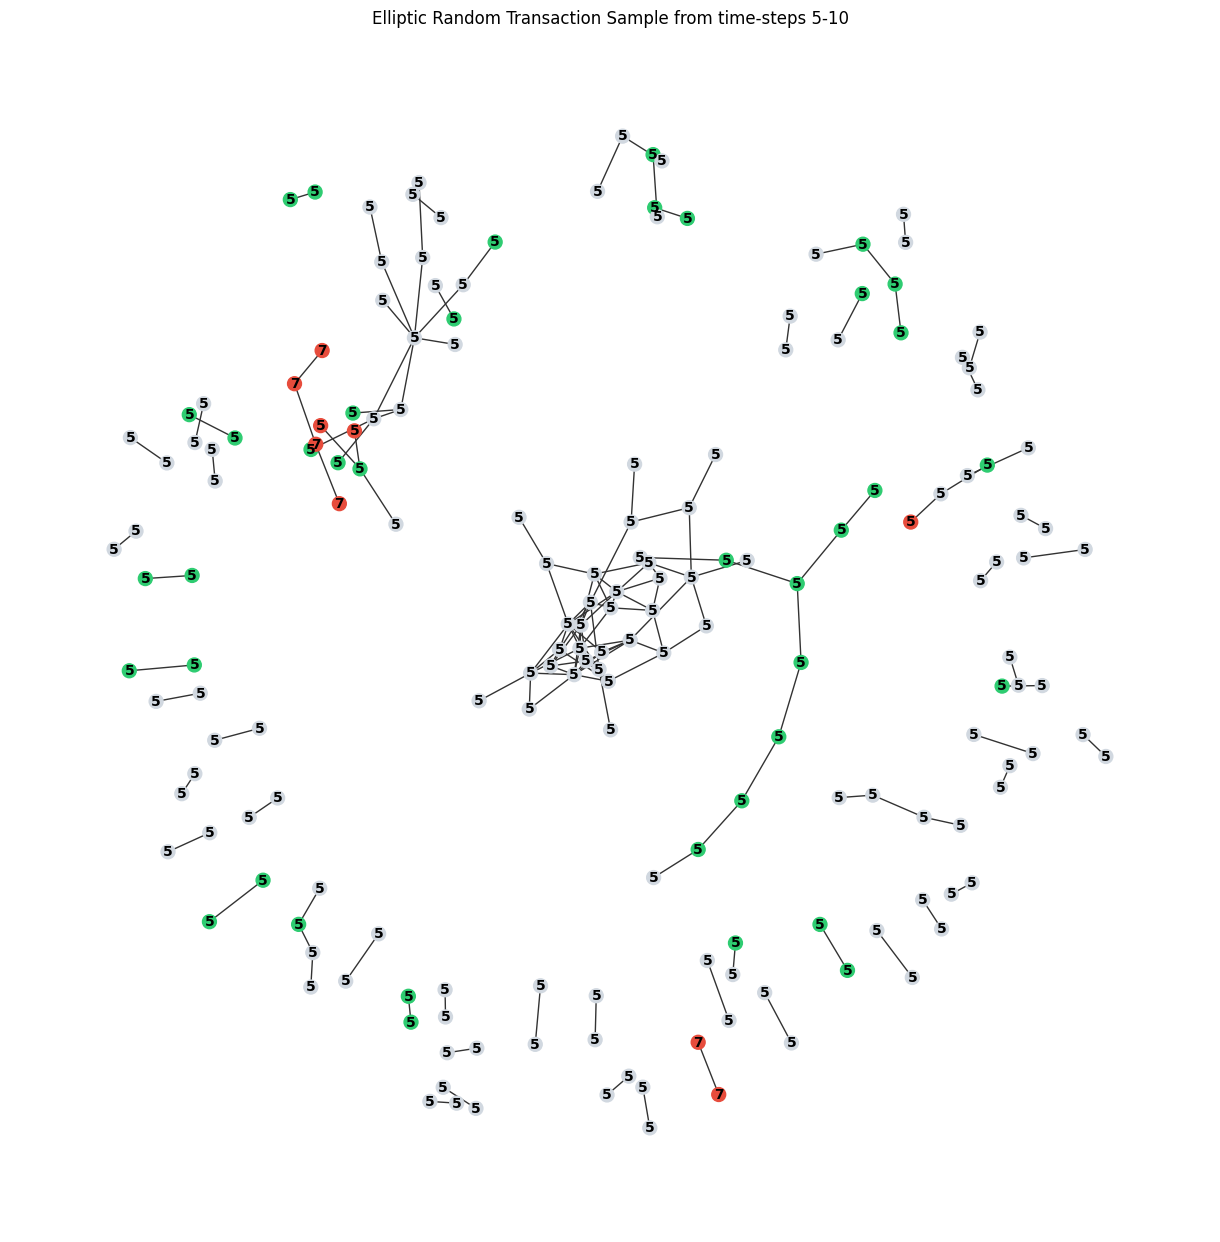

In [45]:
pos = nx.spring_layout(G, k=0.1, iterations=30) # Reduced iterations for MVP speed

plt.figure(figsize=(12,12))
nx.draw(G, pos, node_color=colors, node_size=100, edge_color="#333", with_labels=False)
nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_color="black", font_weight="bold")
plt.title("Elliptic Random Transaction Sample from time-steps 5-10")
plt.show()

For visualization, a larger part of illicit transaction was plotted. 

The nodes between the different timesteps are not connected. Initial analysis shows that the labeled nodes are connected between transactions. it might be easier to predict for unknowns which are connected to labeled nodes. 


### Check for Negatives

In [ ]:
# for NMF implementation, check for negative values in the features
features[features < 0].count().loc[lambda x: x>0]

lf_1     177229
lf_2     167489
lf_3      95600
lf_4     178585
lf_5     189790
          ...  
af_68    179079
af_69    178299
af_70    182964
af_71    151367
af_72    151513
Length: 165, dtype: int64